# EDA Titanic


### Introduction
First of all let's take a look at our data. Let's load it:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
base_path = Path(".")

df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')
print(df.shape)
df.head(10)

(891, 11)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,NaN,NaN,S


So we have 891 records, 11 columns (not including ID column). The `Survived` target column is our target column, the rest are measures. Here are some notes:
- we can extract from `Name` the titles like Mr, Mrs, Master, Miss (and maybe more) - this characteristic may provide some additional info
- we could probably extract some data from the ticket, but I will skip it (more appropriate for a professional analysis)
- not everyone apparently had cabin, we need to introduce "No cabin" value
- there may be some linked features like, probably higher `pclass` will result in a higher `fare`, or extracting titles from `names` may make `sex` needless, some info might be redundant or similar.

---
### Missing values

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      793 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


There are some missing values as it can be seen above. We will need to do something with `Age`, `Fare`, `Embarked`, and also `Cabin` which will require special attention. The types are allright.

---
## Exploratory Feature  analysis

#### Numerical features:

In [3]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,793.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,33.123938
std,0.486592,0.836071,14.526497,1.102743,0.806057,51.578312
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.925000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.500000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.275000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


1. 38% of passengers survived, so the target classes are imbalanced. For ML purposes, we should aim to balance the classes.
2. Most people were in 3 rd class

In [4]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

2. and 1st class had the highest survivability, 3rd having the worst
3. Avg age is 29 +- 14 years, quite young, here is the chart of survavibility by age groups of 10 years

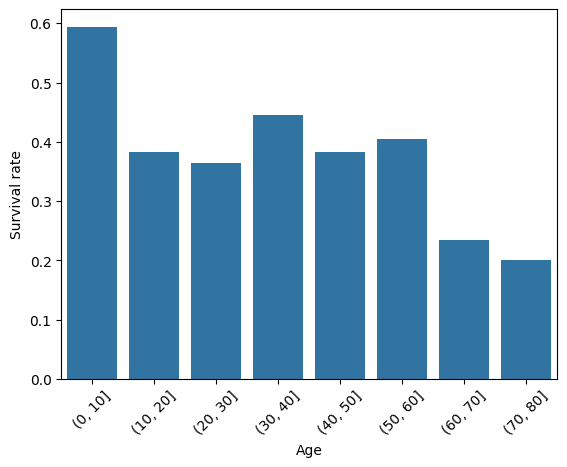

In [34]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80]
)

survival_by_age = df.groupby("AgeGroup", observed=True)["Survived"].mean()

sns.barplot(
    x=survival_by_age.index.astype(str),
    y=survival_by_age.values
)

plt.xticks(rotation=45)
plt.ylabel("Survival rate")
plt.xlabel("Age")
plt.show()

3. People aged 60+ have poor survavibilty, and children were probably prioritised when it came to evacuation. And also let's look at the imputing problem, my proposition is to place it based on avg people class x sex:


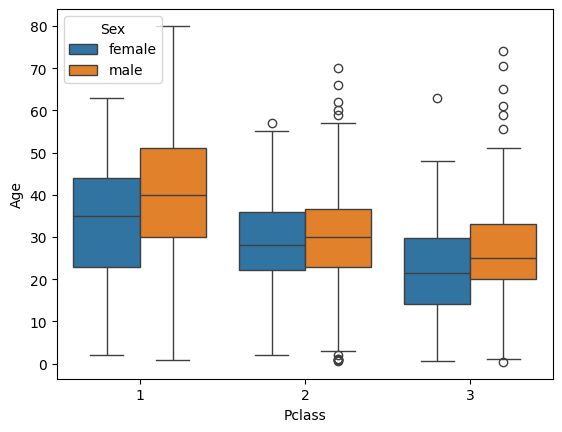

In [6]:
sns.boxplot(
    data=df,
    x="Pclass",
    y="Age",
    hue="Sex"
)
plt.show()

3. Well so we can see here that this way of imputing should be fine
4. Fare mean is 2x bigger than median of 14.5, the highest being 512

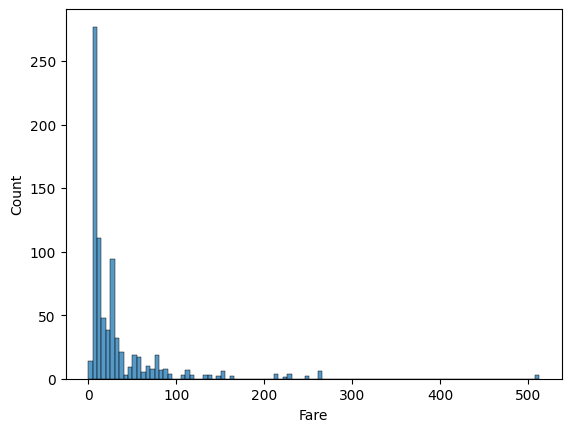

In [7]:
sns.histplot(data=df, x="Fare")
plt.show()

4. cd. 512 is quite far away, most tickets cost below 100, also with fare imputing, same idea as with age:

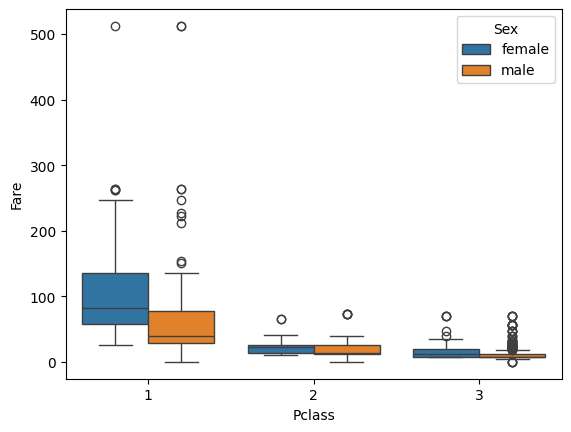

In [8]:
sns.boxplot(
    data=df,
    x="Pclass",
    y="Fare",
    hue="Sex"
)
plt.show()

5. SibSp, Parch  - over 50% of people were without spouse/siblings aboard, and 75% without children or parents, we can probably introduce a combined feature "familyMembers" 

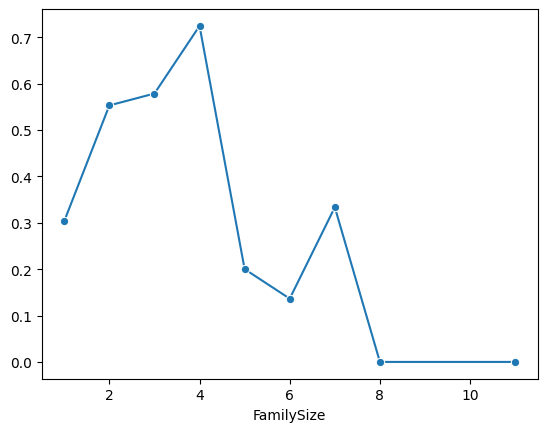

In [9]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1 # +1 for the passenger themselves
survival_by_family = df.groupby("FamilySize")["Survived"].mean()

sns.lineplot(
    x=survival_by_family.index,
    y=survival_by_family.values,
    marker="o"
)
plt.show()

Categorical features:

In [10]:
df.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


1. Let's see if titles matter when it comes to names:

In [11]:
df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.")
df["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [12]:
pd.crosstab(
    df["Title"],
    df["Survived"],
    normalize="index"
)

Survived,0,1
Title,,
Capt,1.000000,0.000000
Col,0.500000,0.500000
Don,1.000000,0.000000
Dr,0.571429,0.428571
Jonkheer,1.000000,0.000000
Lady,0.000000,1.000000
Major,0.500000,0.500000
Master,0.425000,0.575000
Miss,0.302198,0.697802


1. As seen Titles are quite important, but what I would do is change rare categories other than `Mr`, `Miss`, `Mrs` and `Master` to `Rare` 
2. 64% od passengers were men, here is survavibility by sex:

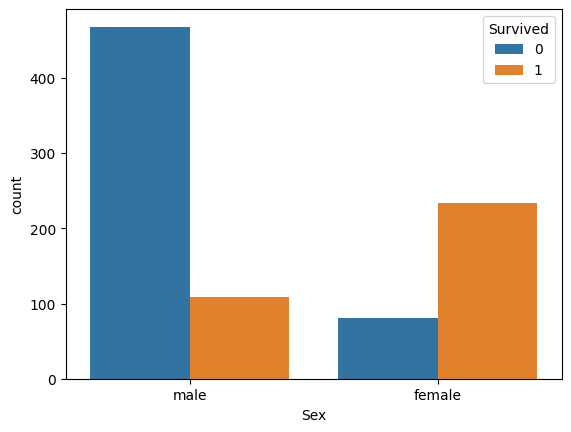

In [13]:
sns.countplot(
    data=df,
    x="Sex",
    hue="Survived"
)
plt.show()

2. as seen, women had much better survavibility rate
3. Tickets - some people shared the same ticket numbers, but most values are unique. We could extract features like group size per ticket or ticket prefixes, but as decided before I won't be analysing it further.
4. Cabin - not everybody had a cabin, let's see if having it benefited in any way:

In [14]:
df["HasCabin"] = df["Cabin"].notna()
df.groupby("HasCabin")["Survived"].mean()

HasCabin
False    0.299854
True     0.666667
Name: Survived, dtype: float64

4. Well actually having a cabin has a huge impact, it also appears that there are shared cabins, and we can extract data from it (there appears to be sections / levels like A/B/C/D), also some people had multiple cabins separated by spaces, let's check it!

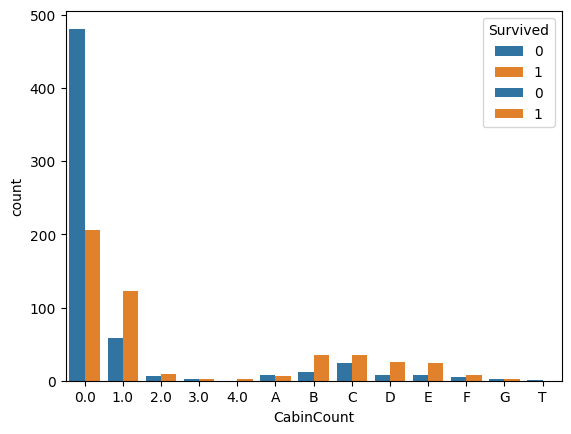

In [15]:
df["CabinCount"] = df["Cabin"].str.split().str.len().fillna(0)

sns.countplot(
    data=df,
    x="CabinCount",
    hue="Survived"
)

df["Deck"] = df["Cabin"].str[0]

decks = sorted(df["Deck"].dropna().unique())

sns.countplot(
    data=df,
    x="Deck",
    hue="Survived",
    order=decks
)

plt.show()


4. On decks A and T, the number of passengers who died was higher than the number who survived, while the opposite was observed for all other decks. The number of cabins assigned to a passenger does not show a clear relationship with survival, suggesting that having a cabin may be more relevant than the number of cabins.
5. Embarked - only 3 missing values, easy to fill, we can see if it had any difference at all:

<Axes: xlabel='Embarked', ylabel='Survived'>

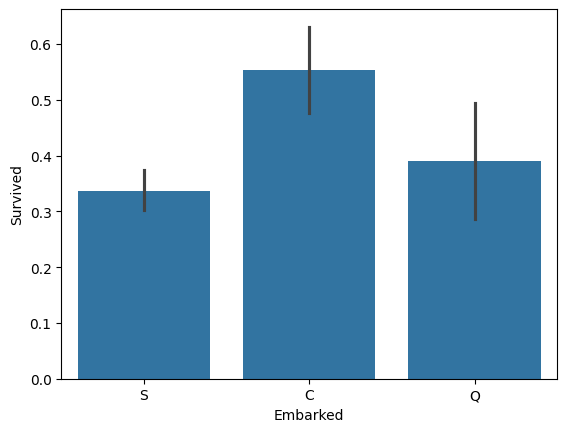

In [16]:
sns.barplot(data=df, x="Embarked", y="Survived")

5. Actually there is some difference, but maybe it's related more to other characteristics like wealthness or something. ML will determine that, but it's important to remember about it, that it can be suspicious to some extent.

In [17]:
pd.crosstab(df["Embarked"], df["Pclass"], normalize="index")

Pclass,1,2,3
Embarked,,,
C,0.505952,0.101190,0.392857
Q,0.025974,0.038961,0.935065
S,0.197205,0.254658,0.548137


5. Yep, it is related that in the city 'C' there were 50% of passangers in the 1st class.

# Outliers

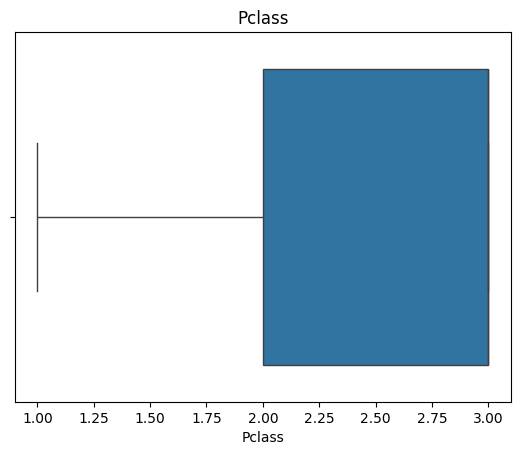

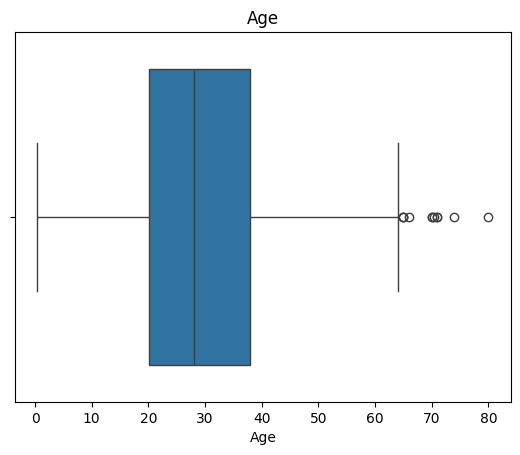

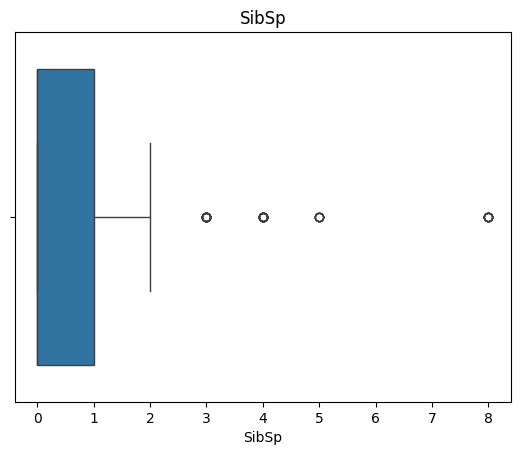

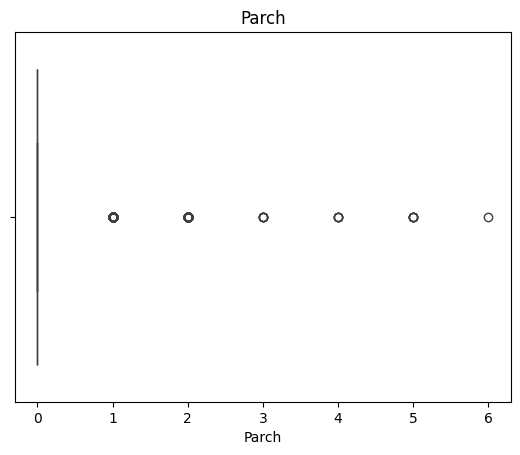

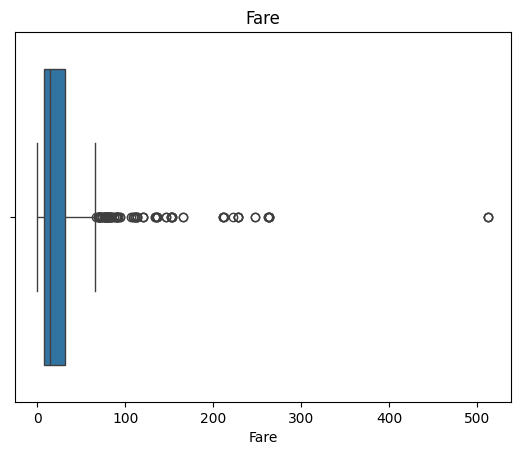

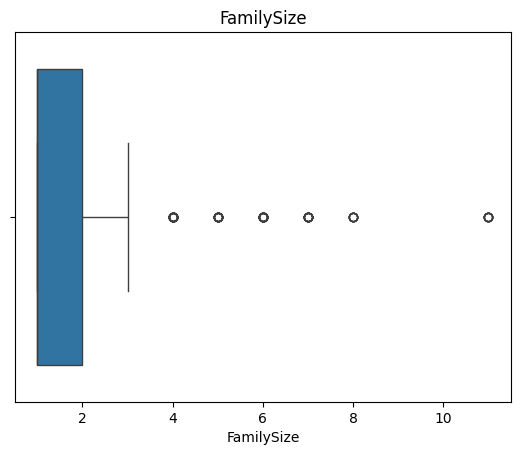

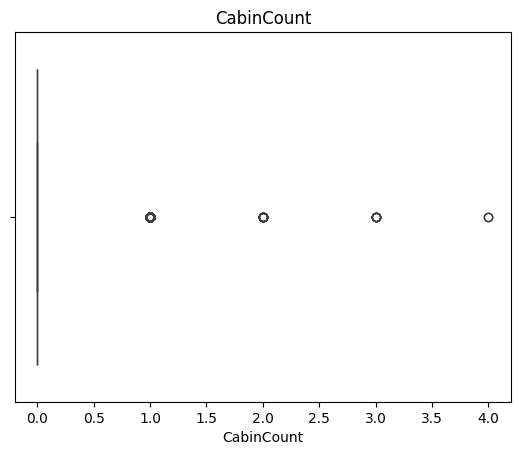

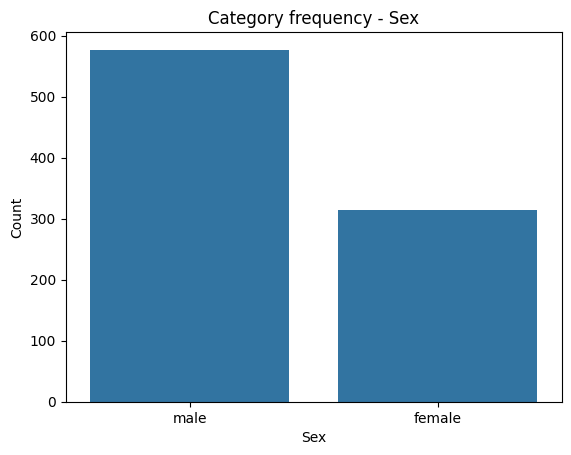

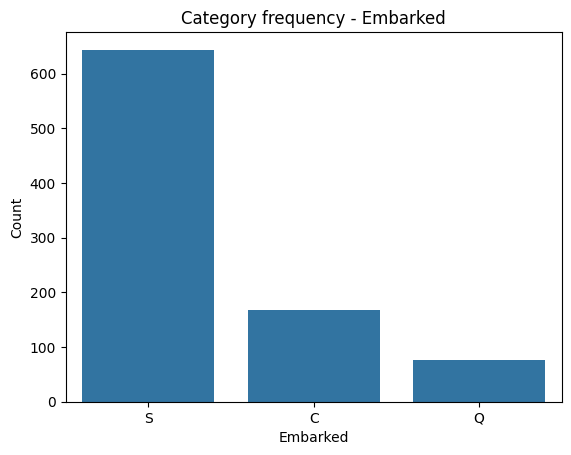

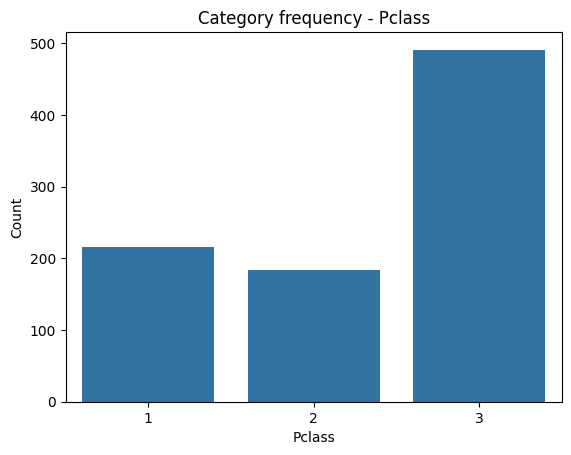

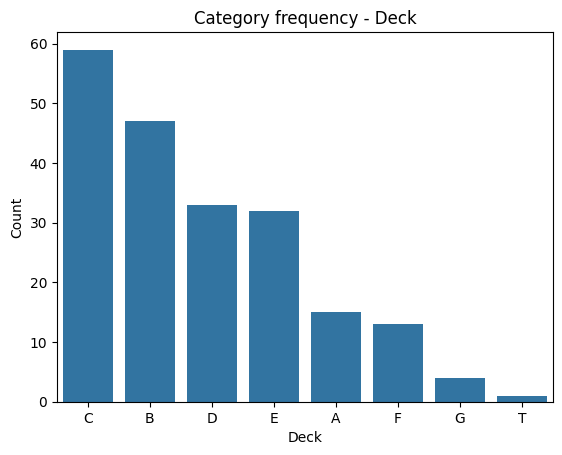

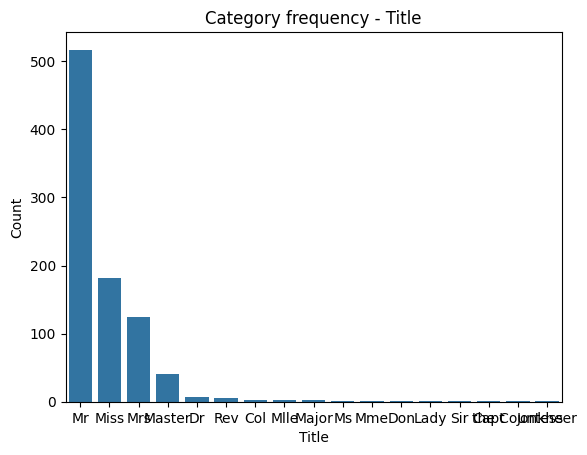

In [18]:
numeric_cols = df.select_dtypes(include=np.number).columns.drop(["Survived"])

for col in numeric_cols:
    plt.figure()
    sns.boxplot(data=df, x=col)
    plt.title(col)
    plt.show()

categorical_cols = ["Sex", "Embarked", "Pclass", "Deck", "Title"]

for col in categorical_cols:
    counts = df[col].value_counts()

    plt.figure()
    sns.barplot(x=counts.index, y=counts.values)
    plt.title(f"Category frequency - {col}")
    plt.ylabel("Count")
    plt.show()

Except for Title, which we said we are going to replace rare categories with rare, it seems correct, there are no clear outliers, everything seems normal. We can leave 500+ outlier in Fare as it could actually be real. For some models this value can be harmful, but generally it should be alright.
Let's replace quickly rare categories in Title:

In [19]:
common_titles = ["Mr", "Miss", "Mrs", "Master"]

df["Title"] = df["Title"].where(
    df["Title"].isin(common_titles),
    "Rare"
)

## Distributions

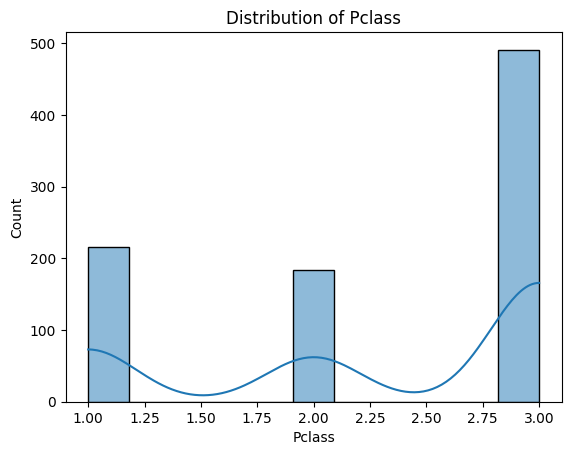

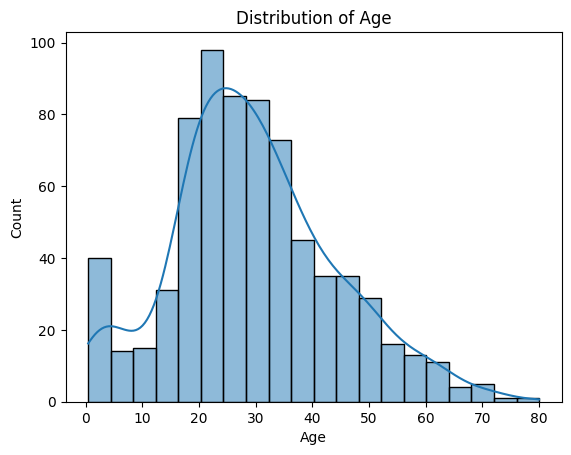

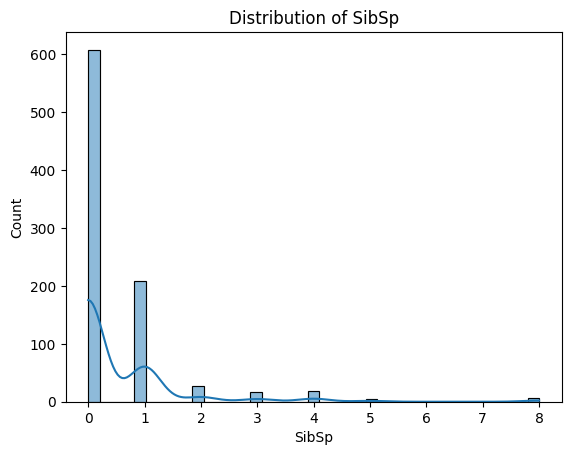

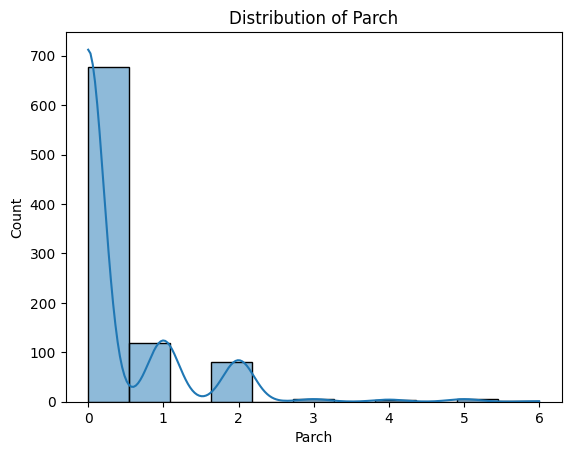

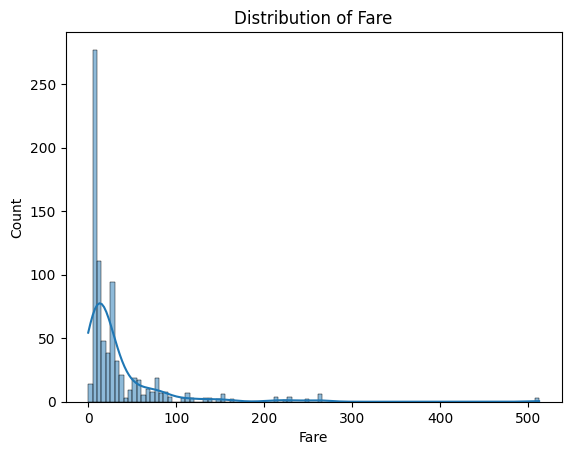

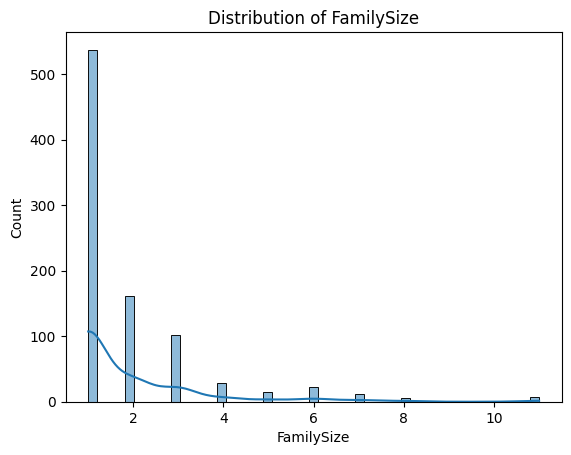

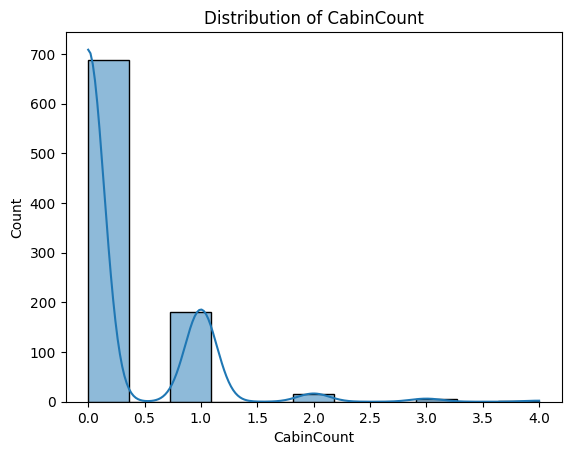

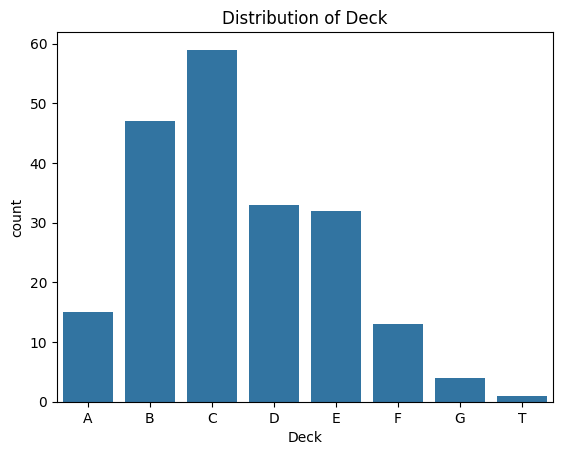

In [20]:
numeric_cols = df.select_dtypes(include=np.number).columns.drop("Survived")

for col in numeric_cols:
    plt.figure()
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


categorical_cols = ["Deck"]

for col in categorical_cols:
    plt.figure()
    sns.countplot(
        data=df,
        x=col,
        order=sorted(df[col].dropna().unique())
    )
    plt.title(f"Distribution of {col}")
    plt.show()

Summary:
1) Pclass - oridinal distribution
2) Age - normal distribution
3) SibSp - right-skewed
4) Parch - right-skewed
5) Fare - right-skewed - we could use log-transformation - see below
6) FamilySize - right-skewed
7) Deck - normal distribution

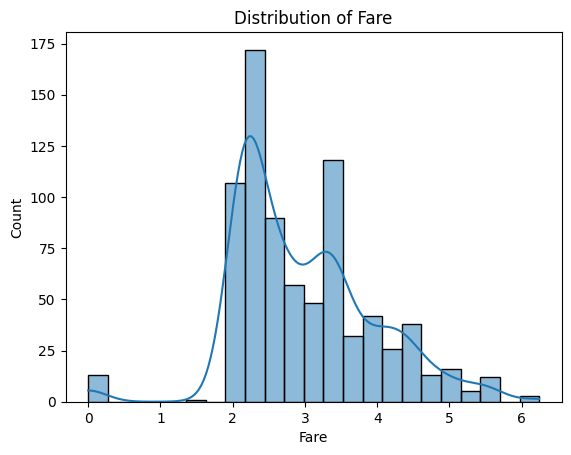

In [21]:
df["Fare"] = np.log1p(df["Fare"])

plt.figure()
sns.histplot(data=df, x="Fare", kde=True)
plt.title(f"Distribution of Fare")
plt.show()

Seems to be better than the original distribution

## Heatmap

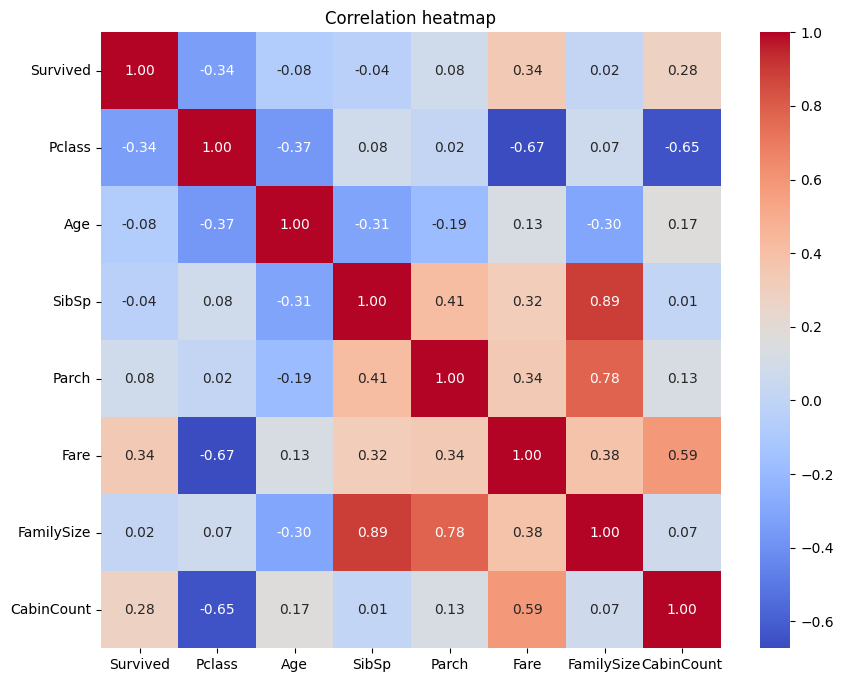

In [22]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation heatmap")
plt.show()

The heatmap shows several noticeable (linear!) relationships between the numerical features. Pclass has a moderate negative correlation with Survived (-0.34), while Fare has a moderate positive correlation (0.34), which is consistent with the previous observations that passengers from higher classes and passengers who paid more were more likely to survive.

There is also a strong negative correlation between Pclass and Fare (-0.67), suggesting that passengers from higher classes generally paid higher fares. FamilySize is strongly correlated with both SibSp (0.89) and Parch (0.78), which is expected since it was directly derived from these two features.

Age has only a weak correlation with Survived (-0.08), suggesting that there is no strong linear relationship between age and survival. This does not necessarily mean that age is irrelevant, as the previous age-group analysis showed differences in survival rates.

Overall, the correlations are consistent with the previous analysis and do not reveal any unexpected relationships. The categorical features are not included in this heatmap because Pearson correlation is not appropriate for them.


## Final transformation matrix

Here is also encoding mentioned - should be self-explanatory, with Pclass - it is ordinal, since lower value = better accomodation.

And there will be no NaNs.

This is my final decision:

In [24]:
from IPython.display import display, HTML

df_transformations = pd.read_csv("transformations.csv").replace(np.nan, "", regex=True)
display(HTML(df_transformations.to_html(index=False)))

Column,Decision,Imputation,Encoding,Scaling,Reason
PassengerId,Drop,,,,No meaning
Survived,Target,,Numeric,,Target variable
Pclass,Keep,,Ordinal / numeric,,Strong relationship with survival
Name,Drop,,,,Drop name
Sex,Keep,,Binary,,Strong relationship with survival
Age,Impute,Median by Pclass and Sex,Numeric,,Strong relationship with survival
SibSp,Keep,,Numeric,,"Shows relationship with survival, used to create FamilySize"
Parch,Keep,,Numeric,,Shows relationship with survival; also used to create FamilySize
Ticket,Drop,,Numeric,,Potentially useful information but outside the scope of this analysis
Fare,Impute,Median by Pclass and Sex,Numeric,Log-transform,Strong relationship with survival
